# L4: Building the Code Knowledge Graph

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In this notebook, you'll build a **Code Knowledge Graph** from imports, function calls, and co-edits, and compare graph-based retrieval against traditional approaches like regex matching and text search, to see when structured memory gives AI agents an edge.

You'll:
- Construct a graph from **nodes** (files, functions) and **edges** (imports, calls, co-edits), starting with a small sample and scaling up to a real codebase (~200 files, ~1,200 symbols)
- **Deduplicate and prepare** the graph for retrieval
- Implement two-step retrieval: an **anchor** node found via similarity search, followed by **PageRank** traversal to surface the most relevant nodes
- Test performance on **easy** (lexically similar) vs. **multi-hop** (structurally distant) queries
- See how the graph handles **codebase edits**, with near-zero append cost for new nodes
- Review real benchmark results (HTTPie, Django) showing gains in tool calls, tokens, time-to-first-edit, and overall cost when Code Knowledge Graphs are injected into an agent's context

In [2]:
import helper as _lesson_helper
_lesson_helper.ensure_schema()

import sys
from pathlib import Path
sys.path.insert(
    0,
    str(Path.cwd().parent if Path("notebook.ipynb").exists()
        else Path.cwd()),
)
from course_lab.sandbox import ensure_ready
_ = ensure_ready()

[helper] Provisioning the course user via scripts/bootstrap_oracle_free.sh...
[setup] Database is reachable.
[setup] Environment is ready.


<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download"</em>.</p>
</div>

## Connect to Database

Connect to the module and initialize the environment you'll use throughout the lesson.

In [3]:
import sys
from pathlib import Path
sys.path.insert(
    0,
    str(Path.cwd().parent if Path("notebook.ipynb").exists()
        else Path.cwd()),
)

from course_lab.m3_lab import connect_module3

s = connect_module3()
cfg, domain, mem = s.cfg, s.domain, s.mem
print(s.summary())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Domain     : coding_agent
Backend    : real
Memory     : seeded (the code graph is loaded later, when we open the real codebase)


## Build a small Code Knowledge Graph

Define a handful of starter nodes (files, functions) and edges (imports, calls, containment) by hand, to see the graph's building blocks before scaling up.

In [4]:
starter_nodes = [
    # (id, kind, label)
    ("file:retriever.py",   "file",   "retriever.py"),
    ("file:graph_store.py", "file",   "graph_store.py"),
    ("file:auth.py",        "file",   "auth.py"),
    ("file:api.py",         "file",   "api.py"),
    ("file:test_retriever.py", "file", "test_retriever.py"),
    ("fn:seed_ppr",         "symbol", "seed_ppr()"),
    ("fn:walk_edges",       "symbol", "walk_edges()"),
    ("fn:verify_token",     "symbol", "verify_token()"),
]

In [5]:
starter_edges = [
    ("file:retriever.py",   "fn:seed_ppr",         "contains"),
    ("file:retriever.py",   "fn:walk_edges",       "contains"),
    ("file:retriever.py",   "fn:verify_token",     "contains"),
    # retriever imports graph_store
    ("file:retriever.py",   "file:graph_store.py", "import"),
    # api imports auth
    ("file:api.py",         "file:auth.py",        "import"),
    # api imports retriever
    ("file:api.py",         "file:retriever.py",   "import"),
    # seed_ppr() calls walk_edges()
    ("fn:seed_ppr",         "fn:walk_edges",       "call"),
    # verify_token() calls seed_ppr()
    ("fn:verify_token",     "fn:seed_ppr",         "call"),
    # shipped together
    ("file:retriever.py",   "file:graph_store.py", "co_edit"),
    ("file:retriever.py",   "file:test_retriever.py", "co_edit"),
    ("file:graph_store.py", "file:test_retriever.py", "co_edit"),
    # shipped together
    ("file:api.py",         "file:auth.py",        "co_edit"),
]

In [6]:
from collections import Counter
print(f"{len(starter_nodes)} nodes, {len(starter_edges)} edges")
print("edges by kind:", dict(Counter(k for *_e, k in starter_edges)))

8 nodes, 12 edges
edges by kind: {'contains': 3, 'import': 3, 'call': 2, 'co_edit': 4}


## Storing as a property graph

Create the node and edge tables in Oracle and load the starter graph as a queryable property graph.

In [7]:
from course_lab.m3_lab import starter_reset, show_starter_tables

with mem._pool.acquire() as conn:
    cur = conn.cursor()
    starter_reset(cur)

    cur.execute("""
        CREATE TABLE STARTER_GRAPH_NODES (
            id    VARCHAR2(100) PRIMARY KEY,   -- e.g. 'file:retriever.py'
            kind  VARCHAR2(20),                -- 'file' or 'symbol'
            label VARCHAR2(100)
        )""")
    cur.execute("""
        CREATE TABLE STARTER_GRAPH_EDGES (
            eid  NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
            src  VARCHAR2(100),                -- source node id
            dst  VARCHAR2(100),                -- destination node id
            kind VARCHAR2(20),                 -- import | call | co_edit
            CONSTRAINT starter_edge_src
                FOREIGN KEY (src) REFERENCES STARTER_GRAPH_NODES (id),
            CONSTRAINT starter_edge_dst
                FOREIGN KEY (dst) REFERENCES STARTER_GRAPH_NODES (id)
        )""")
    cur.executemany(
        "INSERT INTO STARTER_GRAPH_NODES (id, kind, label) "
        "VALUES (:1, :2, :3)",
        starter_nodes,
    )
    cur.executemany(
        "INSERT INTO STARTER_GRAPH_EDGES (src, dst, kind) "
        "VALUES (:1, :2, :3)",
        starter_edges,
    )
    cur.execute("""
        CREATE PROPERTY GRAPH starter_code_graph
          VERTEX TABLES (
            STARTER_GRAPH_NODES KEY (id)
              PROPERTIES (id, kind, label))
          EDGE TABLES (
            STARTER_GRAPH_EDGES KEY (eid)
              SOURCE      KEY (src) REFERENCES STARTER_GRAPH_NODES (id)
              DESTINATION KEY (dst) REFERENCES STARTER_GRAPH_NODES (id)
              PROPERTIES (kind))""")
    conn.commit()

    show_starter_tables(cur)

print(f"Stored as property graph starter_code_graph: "
      f"{len(starter_nodes)} vertices, {len(starter_edges)} edges "
      f"over two tables.")

=== STARTER_GRAPH_NODES (8 rows) ===
  id                         kind     label
  file:api.py                file     api.py
  file:auth.py               file     auth.py
  file:graph_store.py        file     graph_store.py
  file:retriever.py          file     retriever.py
  file:test_retriever.py     file     test_retriever.py
  fn:seed_ppr                symbol   seed_ppr()
  fn:verify_token            symbol   verify_token()
  fn:walk_edges              symbol   walk_edges()

=== STARTER_GRAPH_EDGES (12 rows) ===
  eid  src                        dst                        kind
    1  file:retriever.py          fn:seed_ppr                contains
    2  file:retriever.py          fn:walk_edges              contains
    3  file:retriever.py          fn:verify_token            contains
    4  file:retriever.py          file:graph_store.py        import
    5  file:api.py                file:auth.py               import
    6  file:api.py                file:retriever.py          imp

## Draw the starter graph

Visualize the small starter graph to see how files, functions, imports, and calls connect.

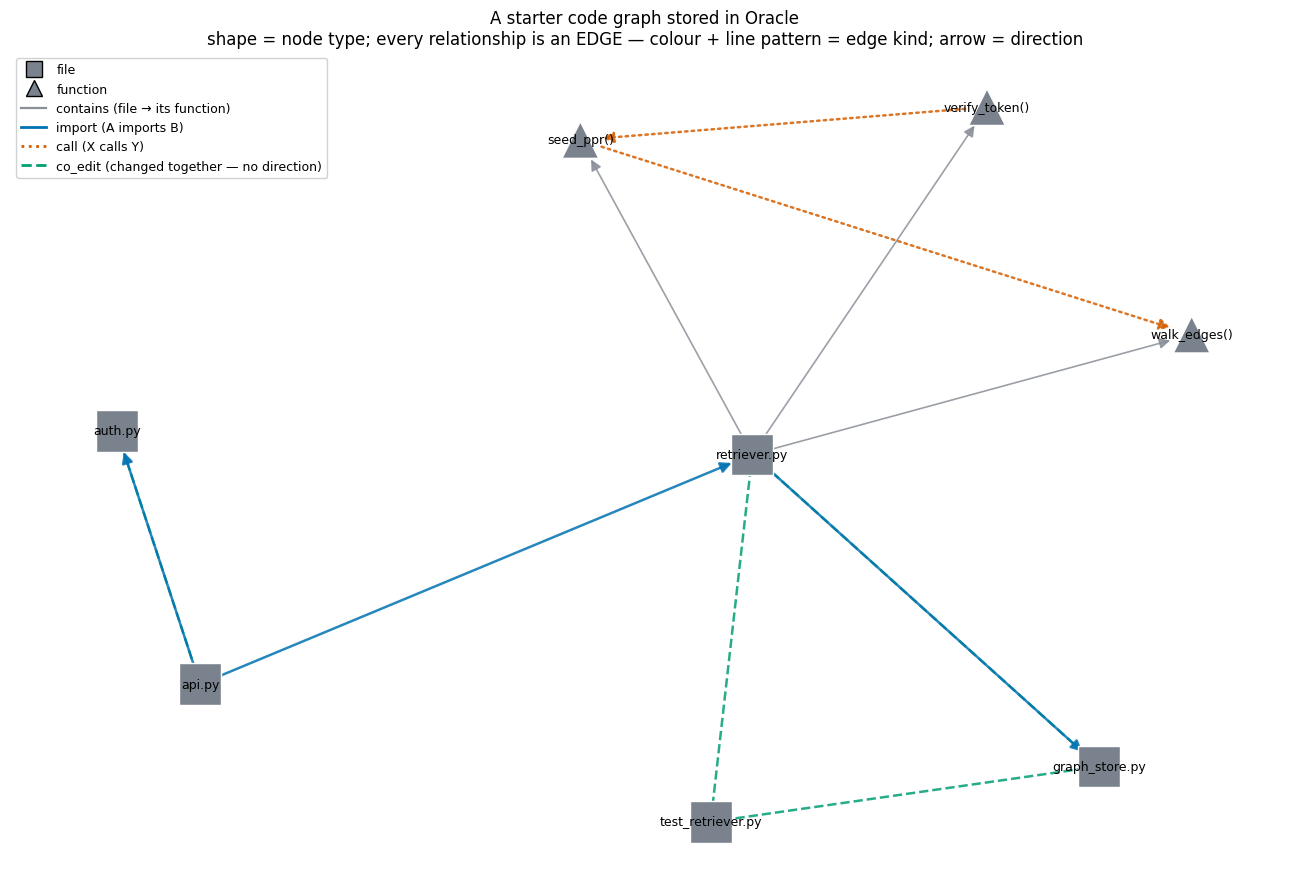

In [8]:
from course_lab.m3_lab import render_starter_graph

render_starter_graph(starter_nodes, starter_edges)


## Querying the small Code Knowledge Graph

Run graph pattern-matching queries (`MATCH`) to pull typed edges and traverse relationships between nodes.

In [9]:
from course_lab.m3_lab import show_match

with mem._pool.acquire() as conn:
    cur = conn.cursor()
    show_match(cur, """
        SELECT a, kind, b FROM GRAPH_TABLE (starter_code_graph
          MATCH (v) -[e]-> (w)
          COLUMNS (v.label AS a, e.kind AS kind, w.label AS b))
        ORDER BY kind, a""", "every typed edge: MATCH (v)-[e]->(w)")
    show_match(cur, """
        SELECT other FROM GRAPH_TABLE (starter_code_graph
          MATCH (v) -[e]- (w)
          WHERE v.id = :f AND e.kind = 'co_edit'
          COLUMNS (w.label AS other))""",
        "what changed together with retriever.py? (undirected MATCH)",
        binds={"f": "file:retriever.py"})


=== every typed edge: MATCH (v)-[e]->(w) ===
  seed_ppr()         --call    -> walk_edges()
  verify_token()     --call    -> seed_ppr()
  api.py             --co_edit -> auth.py
  graph_store.py     --co_edit -> test_retriever.py
  retriever.py       --co_edit -> graph_store.py
  retriever.py       --co_edit -> test_retriever.py
  retriever.py       --contains-> seed_ppr()
  retriever.py       --contains-> walk_edges()
  retriever.py       --contains-> verify_token()
  api.py             --import  -> auth.py
  api.py             --import  -> retriever.py
  retriever.py       --import  -> graph_store.py

=== what changed together with retriever.py? (undirected MATCH) ===
  graph_store.py
  test_retriever.py



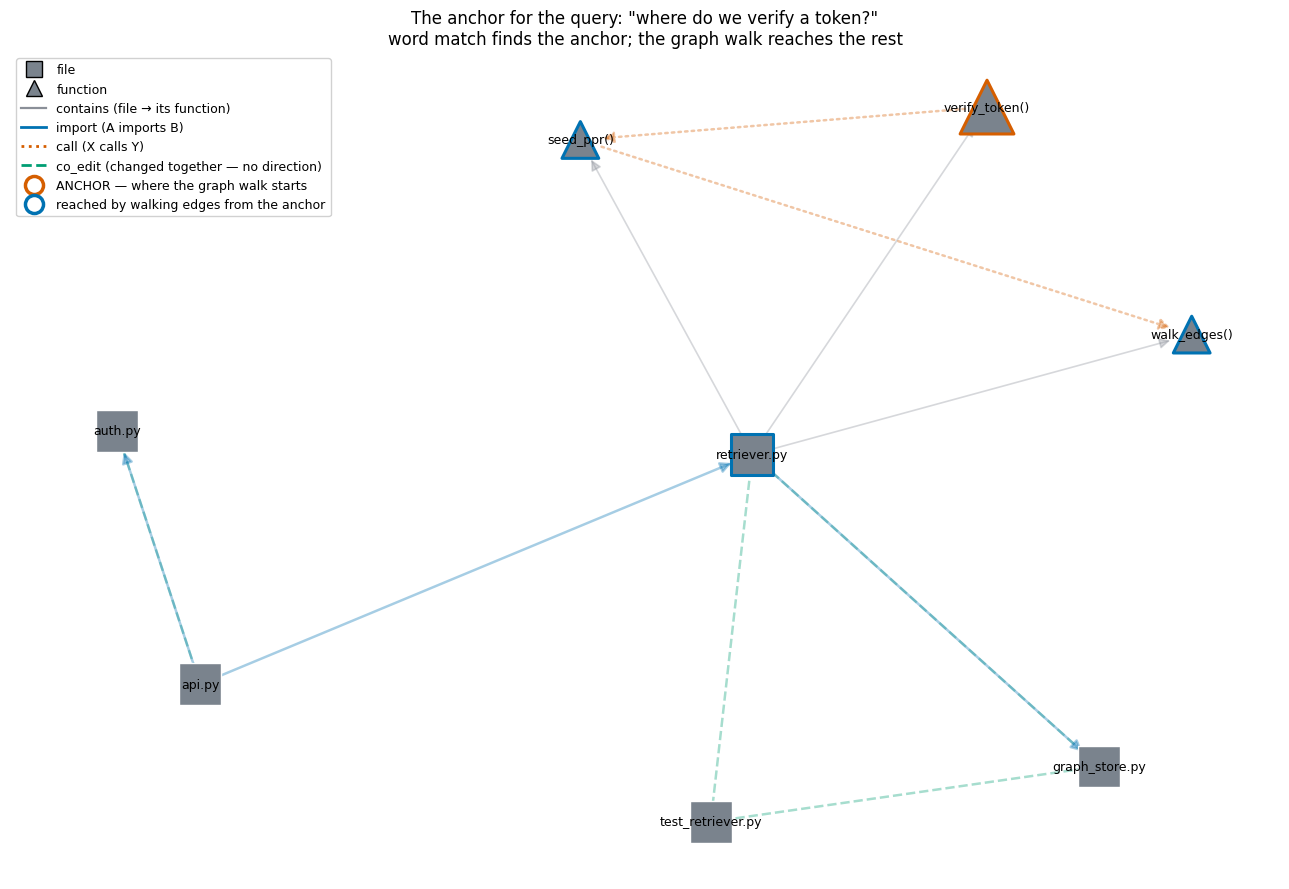

Query   : "where do we verify a token?"
Anchor  : verify_token()   <- best word match (token, verify)
Walk    : verify_token(), retriever.py, seed_ppr(), walk_edges()
None of these share semantic similarity with the query, but the edges from the graph reach them


In [10]:
from course_lab.m3_lab import render_anchor_walk

render_anchor_walk(starter_nodes, starter_edges,
                   query="where do we verify a token?")

## Adding one node to the Graph

Add a new function node and its call edge to the graph, and see how cheaply the structure grows.

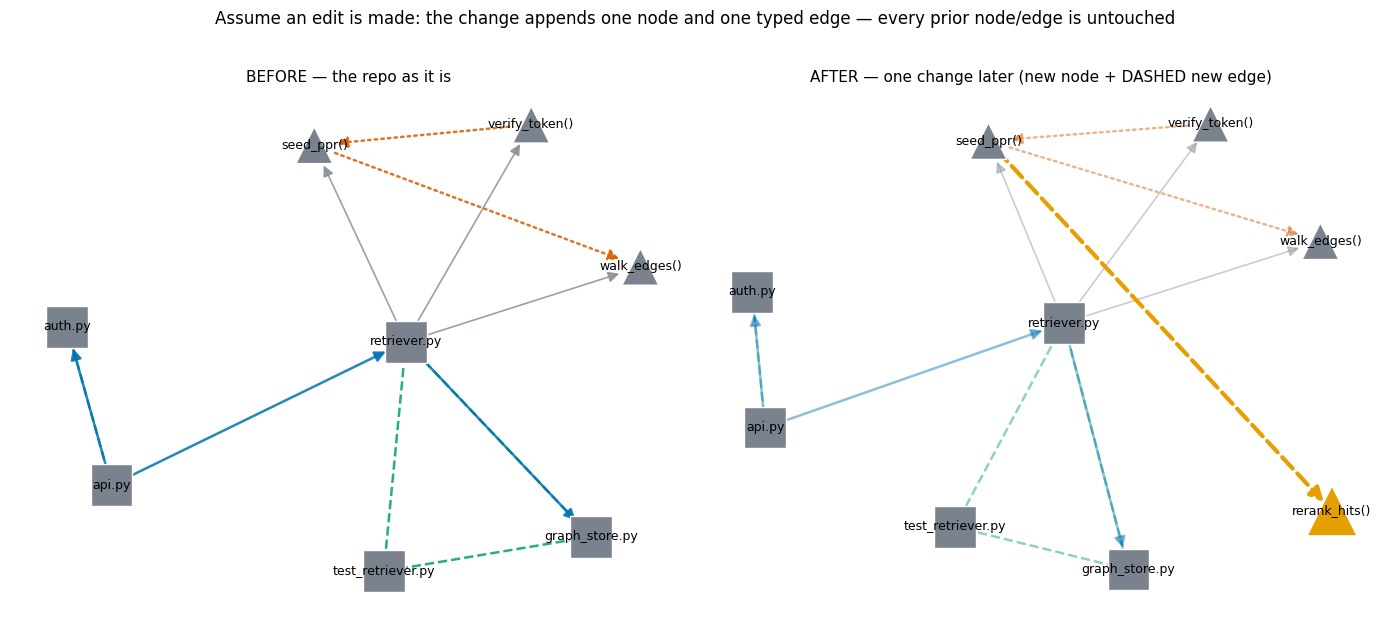

Appended node 'fn:rerank_hits' and edge seed_ppr --call--> rerank_hits.
Minimal MERGE into the existing graph - not destroying and re-creating


In [11]:
from course_lab.m3_lab import render_growth_step

new_symbol = ("fn:rerank_hits", "symbol", "rerank_hits()")
new_edge   = ("fn:seed_ppr", "fn:rerank_hits", "call")

render_growth_step(starter_nodes, starter_edges, new_symbol, new_edge)

## Real Codebase Knowledge Graph

Move from the toy example to a real codebase (~200 files, ~1,200 symbols) and load its raw import/call/co-edit data plus a set of evaluation tasks.

In [12]:
from course_lab.code_graph_parse import load_code_graph
from course_lab.m3_lab import show_raw_code_data, load_real_graph

cg = load_code_graph()
show_raw_code_data(cg, n_files=6, n_edges=6)

nodes, edges, eval_tasks = load_real_graph(s)

=== The codebase the agent remembers: agent_harness ===
208 files, 1259 symbols (functions/classes/methods); edges: {'import': 378, 'call': 1524, 'co_edit': 3299}

Sample files:  __init__.py, __main__.py, api/__init__.py, api/deps.py, api/routes/__init__.py, api/routes/chat.py

What imports what (file -> file):
  __main__.py                  imports  cli/__init__.py
  api/deps.py                  imports  config/settings.py
  api/deps.py                  imports  core/agent_loop.py
  api/deps.py                  imports  core/compaction.py
  api/deps.py                  imports  llm/factory.py
  api/deps.py                  imports  memory/chat_history.py

What calls what (function -> function):
  get_chat_archive           calls  get_settings()
  get_chat_archive           calls  ChatHistoryArchive()
  get_or_create_agent        calls  get_settings()
  get_or_create_agent        calls  AgentConfig()
  get_or_create_agent        calls  AgentLoop()
  get_or_create_agent        calls  Co

## Step 1: Auditing the repo

Score the raw graph before any cleanup, to establish a baseline for how noisy or redundant it is.

In [13]:
from course_lab.memory_audit import audit_scorecard
from course_lab.m3_lab import show_scorecard

before_sc = audit_scorecard(nodes, edges)
show_scorecard(before_sc, label="BEFORE restructure")

=== Act 1: Memory-quality audit (BEFORE restructure) ===
  n_memories         : 1467
  dup_pct            : 0.0429  (4.3% near-duplicate)
  stale_pct          : 0.0000
  contradiction_count: 0
  duplicate clusters : 17 (first 3 shown)
    [1] sym:autonomy/goal.py::Goal.from_dict
        sym:autonomy/goal.py::TaskDAG.from_dict
        sym:autonomy/goal.py::TaskNode.from_dict
    [2] sym:autonomy/goal.py::Goal.to_dict
        sym:autonomy/goal.py::TaskDAG.to_dict
        sym:autonomy/goal.py::TaskNode.to_dict
    [3] sym:core/circuit_breaker.py::CircuitBreaker.__init__
        sym:core/circuit_breaker.py::CircuitBreakerOpen.__init__


## Step 2: Deduplicate

Restructure the graph: folding in retrieval traces and removing redundancy, and compare the before/after scorecards.

In [14]:
from course_lab.memory_graph import build_graph, restructure
from course_lab.m3_lab import show_restructure

traces = mem.list_traces("retrieval")
graph = build_graph(traces, edges, domain=domain.name)
graph_clean, after_sc = restructure(graph, before_sc)

show_restructure(graph, graph_clean, before_sc, after_sc, len(traces))

Co-retrieval traces : 0
Graph nodes         : 1,066 -> 1,063
Graph edges         : 4,951 -> 4,949
dup_pct             : 0.0429 -> 0.0000


## Visualize the graph

Render the full, cleaned graph in Oracle and see its overall shape: how many nodes and edges, and whether it's more dependency-led or co-edit-led.

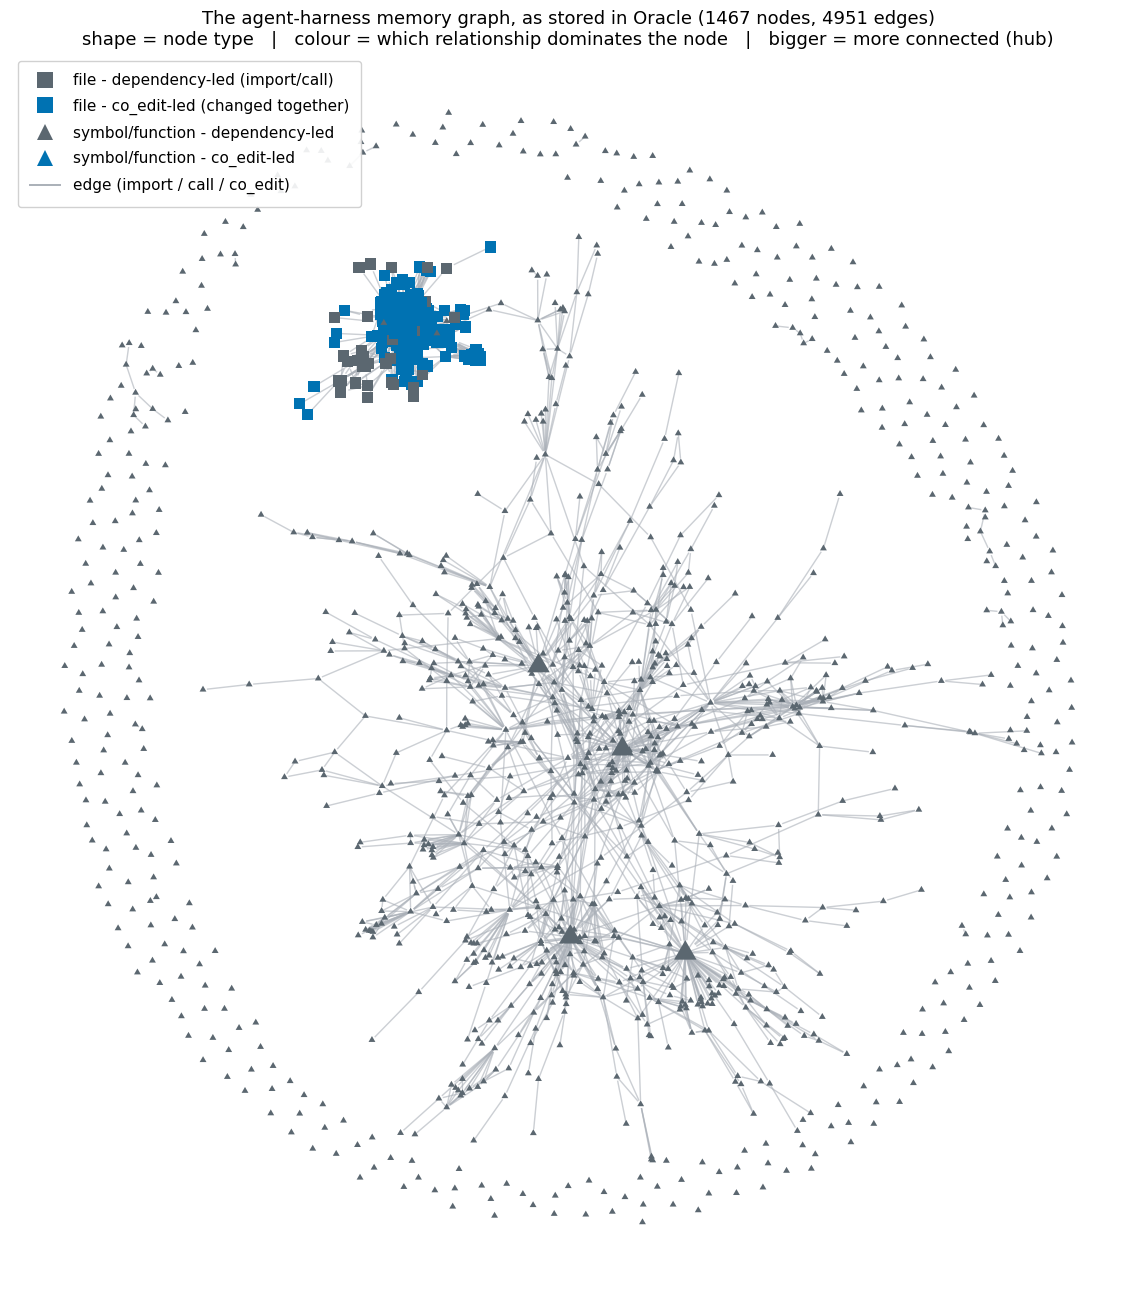

FULL graph in Oracle : 1467 nodes, 4951 edges (by kind={'import': 378, 'call': 1524, 'co_edit': 3299}); dependency-led=1292, co_edit-led=175. PPR walks this whole structure per query.


In [15]:
from course_lab.m3_lab import render_full_graph

stats = render_full_graph(nodes, edges)
print(f"FULL graph in Oracle : {stats['n_nodes']} nodes, "
      f"{stats['n_edges']} edges (by kind={stats['by_kind']}); "
      f"dependency-led={stats['dep_led']}, co_edit-led={stats['co_led']}. "
      f"PPR walks this whole structure per query.")

## Zoom: the file layer

Zoom into just the file-level layer of the graph to see file-to-file relationships on their own.

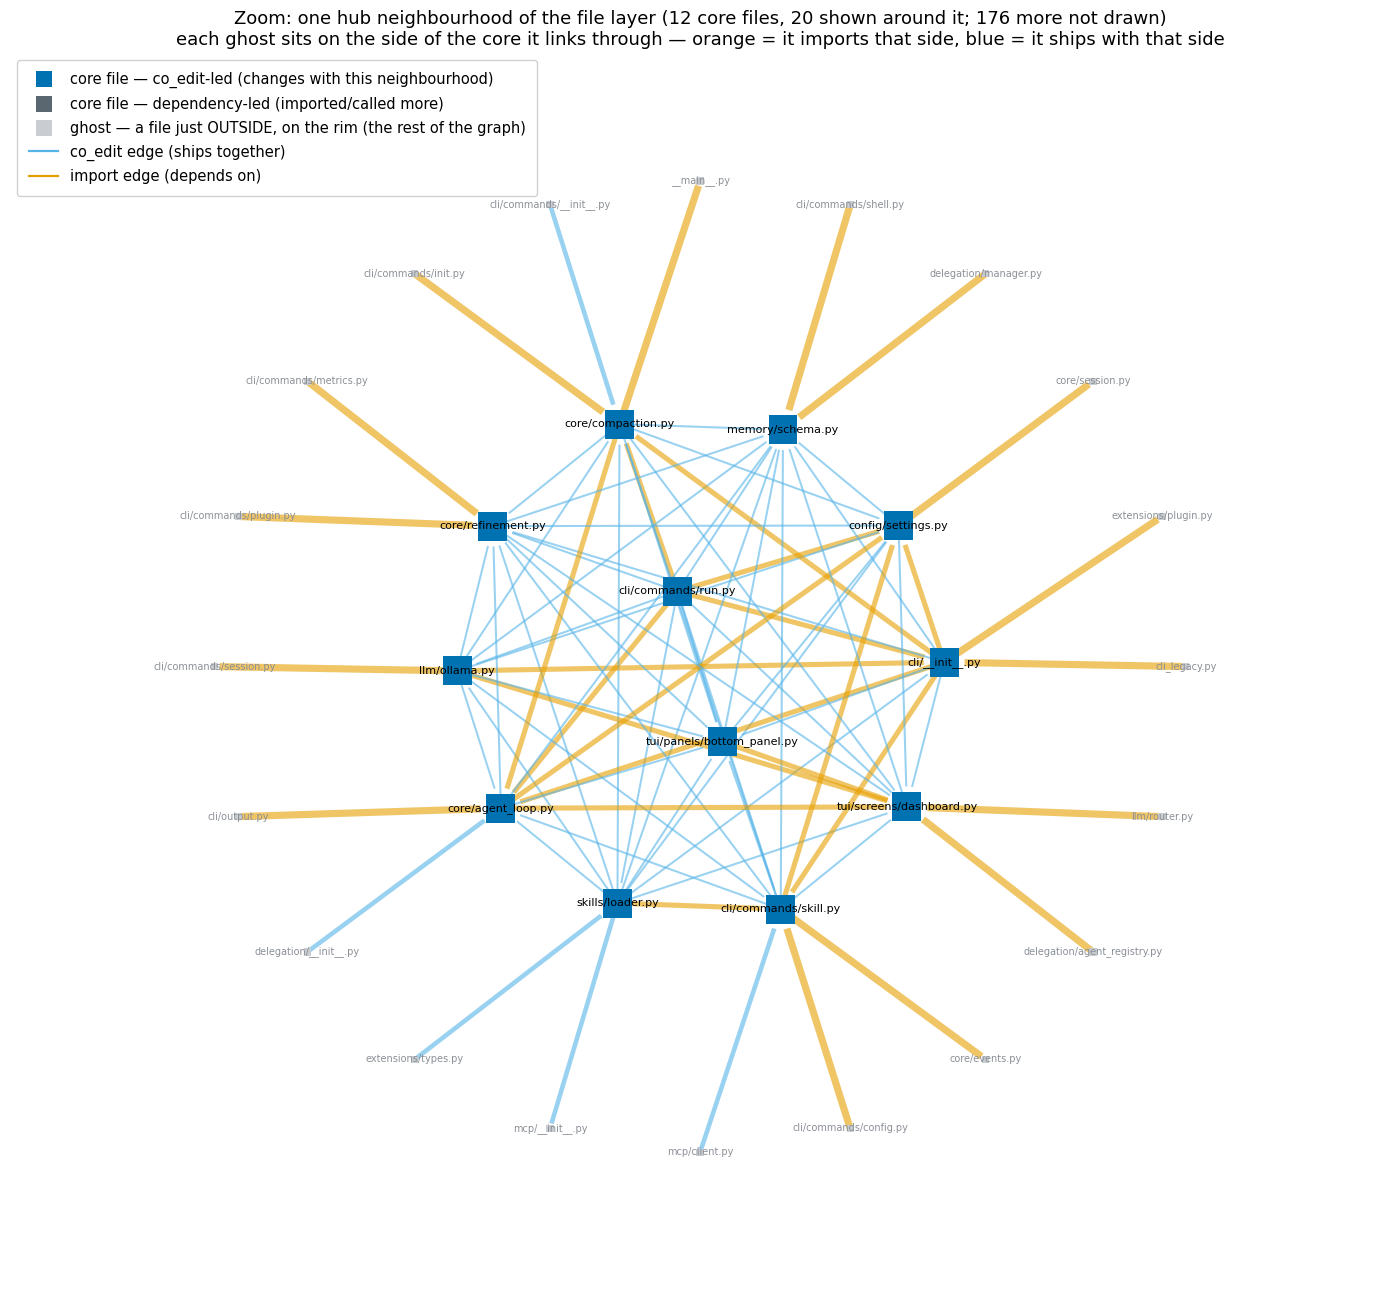

FILE layer in Oracle : 208 files total
This zoom shows      : 12 core files (66 edges among them: 50 co_edit + 16 import) + 20 ghost files around it
Not drawn            : 176 further files of the full layer
Core make-up         : co_edit-led=12, dependency-led=0
Top hub files (core) :
   core/agent_loop.py                 degree 123
   tui/screens/dashboard.py           degree 104
   cli/__init__.py                    degree 102


In [16]:
from course_lab.m3_lab import render_files_only_graph, show_files_zoom

fstats = render_files_only_graph(nodes, edges)
show_files_zoom(fstats)

## Keywords vs PageRank in Knowledge Graph

Run the two-step retrieval pipeline — anchor via similarity search, then PageRank traversal and compare it against keyword-style retrieval on the evaluation tasks.

In [17]:
from course_lab.m3_lab import (peek_hybrid_halves, build_node_embeddings,
                        run_retrieval_eval, narrate_retrieval_comparison)

K, N_ANCHORS = 5, 1

peek_hybrid_halves(eval_tasks, nodes, graph_clean, k=K, n_anchors=N_ANCHORS)
node_emb = build_node_embeddings(nodes)
scored_tasks, results = run_retrieval_eval(eval_tasks, nodes, graph_clean,
                                           k=K,n_anchors=N_ANCHORS,
                                           node_emb=node_emb)

narrate_retrieval_comparison(scored_tasks, results, nodes, k=K)

Query     : When get_chat_archive runs, which internal function does it call?
Anchor(s) : ['sym:api/deps.py::get_chat_archive']   <- the ANCHOR: where the graph walk starts (best word match)
Wanted    : sym:api/deps.py::get_settings   <- the callee; ground truth, NOT in the query
Code KG@5 : ['sym:api/deps.py::get_chat_archive', 'sym:api/routes/memory.py::memory_by_type', 'sym:api/deps.py::get_settings', 'sym:api/routes/sessions.py::new_session', 'sym:memory/chat_history.py::ChatHistoryArchive']
Reached by graph? YES — PPR walked the call edge from the anchor to it

Glossary:
  recall@5 = was the wanted node in the top 5?      (1.0 = yes, 0.0 = no)
  nDCG     = if found, how high did it rank?         (1.0 = rank 1, lower = deeper)
  keywords = plain keyword search (soft word match), no graph
  code KG  = the Code Knowledge Graph walk: keyword ANCHOR, then
             Personalized PageRank follows the typed edges from it
  code KG (sem) = the same walk, but the anchor is picked by MEAN

## Testing on a real coding workflow

Review benchmark results from a real repo (graphify-verification) showing the measured improvement from using the Code Knowledge Graph.

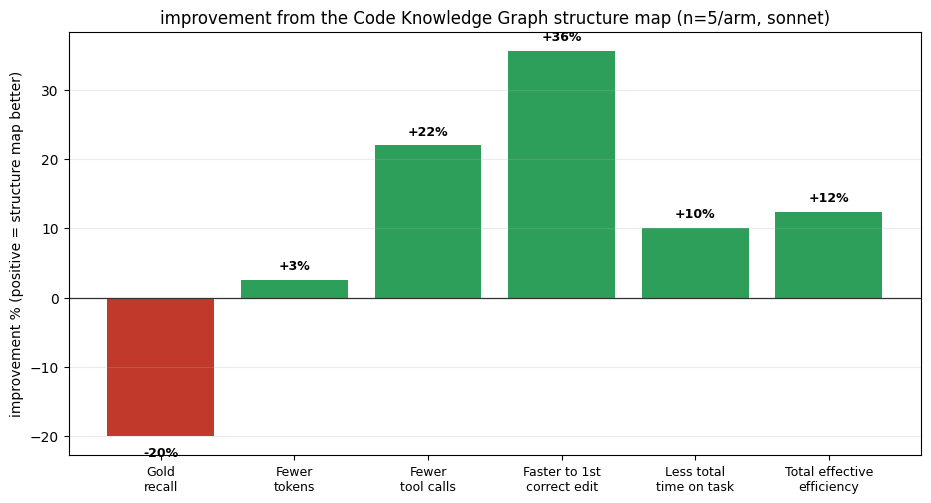

**Result.**
Across 5 runs per arm (sonnet), the treatment (the Code Knowledge Graph structure map — lexical anchor + graph reach) vs control (bare repo):
- gold-file recall (*quality*) 0.5 → 0.4 (-20%)
- **total time on task** 354s → 318s (-10%) — the honest end-to-end clock
- steps to first correct edit 37.6 → 24.2 (-36%) — how soon it reaches a right file
- total tokens 2247857 → 2189318 (-3%)
- tool calls 61.8 → 48.2 (-22%)
- total effective efficiency (cost proxy) $1.38 → $1.21 (-12%)

In [18]:
import matplotlib.pyplot as plt
from course_lab import gv_lab
from IPython.display import Markdown, display

try:
    gv_lab.render_improvement_bars(); plt.show()
    display(Markdown(gv_lab.summarize_text()))
except FileNotFoundError:
    print("graphify-verification results not in this checkout; "
          "run `python lab.py graphify-verify all`.")

## Bigger repo: django

Scale the comparison up to a larger codebase (Django), including a hero-vs-typical case table and a model comparison (Sonnet vs. Haiku).

**django — Claude Code (Haiku).** The **typical task (median across all 10)** — 🟢 graph better · 🟠 ~tie · 🔴 graph worse, every % signed so positive = graph better (N/10 = tasks won):

| metric | **typical task (median across 10)** |
|---|:--|
| total time on task | 🟢 +11% (7/10) |
| steps to first correct edit | 🟢 +7% (6/10) |
| total tokens | 🟢 +5% (7/10) |
| cost (usd) | 🟢 +6% (7/10) |
| gold recall | 🟠 +0% (4/10) |

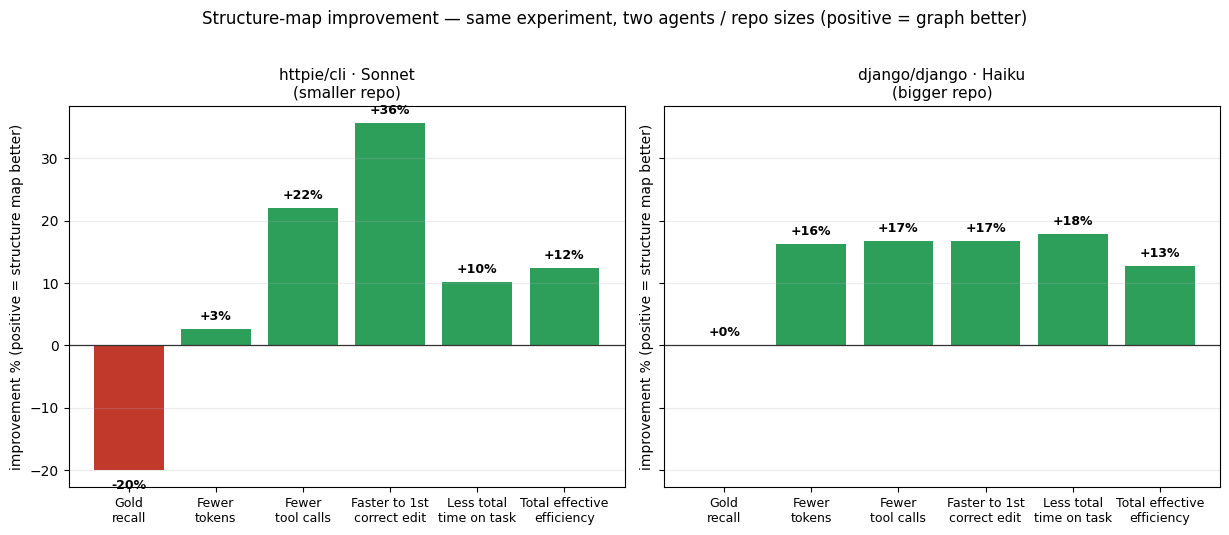

In [19]:
import matplotlib.pyplot as plt
from course_lab import gv_lab
from IPython.display import Markdown, display

display(Markdown(gv_lab.hero_vs_typical_table_md("django_cache")))
gv_lab.render_sonnet_vs_haiku(); plt.show()

## All results

See the full benchmark suite across all task, time-on-task, per-task breakdown, and pooled results, with a pointer to the full write-up.

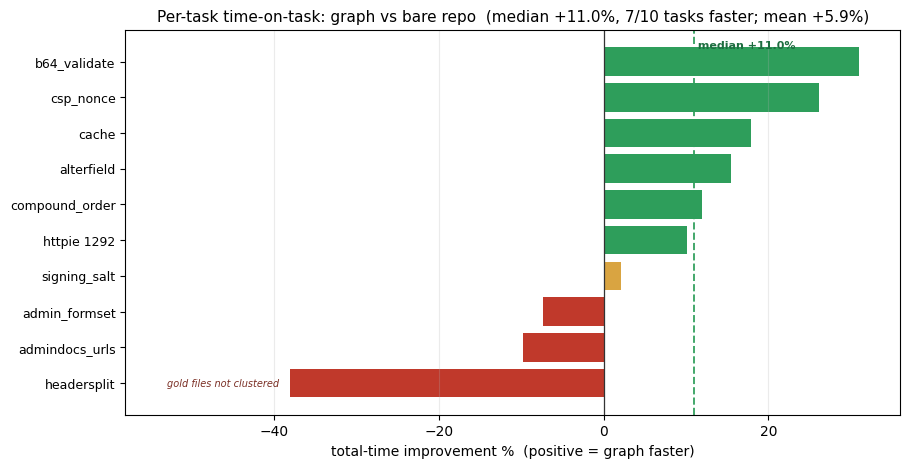

**Per-task** (sorted by time-on-task; + = graph faster):

| Task | Label | total time on task | steps to first correct edit | total tokens | tool calls | cost (usd) | gold recall |
|---|---|---|---|---|---|---|---|
| django_b64_validate | unfavorable | 🟢 +31% | 🔴 -78% | 🟢 +43% | 🔴 -35% | 🟢 +21% | 🟠 +0% |
| django_csp_nonce | unfavorable | 🟢 +26% | 🟢 +39% | 🟢 +26% | 🟢 +20% | 🟢 +24% | 🟢 +33% |
| django_cache | favorable | 🟢 +18% | 🟢 +17% | 🟢 +16% | 🟢 +17% | 🟢 +13% | 🟠 +0% |
| django_alterfield | favorable | 🟢 +15% | 🔴 -44% | 🟢 +19% | 🔴 -9% | 🟠 -0% | 🟠 +0% |
| django_compound_order | mixed | 🟢 +12% | 🟢 +3% | 🟢 +7% | 🟢 +10% | 🟢 +7% | 🔴 -20% |
| httpie_1292 | favorable | 🟢 +10% | 🟢 +36% | 🟢 +3% | 🟢 +22% | 🟢 +12% | 🔴 -20% |
| django_signing_salt | mixed | 🟢 +2% | 🟢 +26% | 🟢 +2% | 🟢 +2% | 🟢 +6% | 🟢 +11% |
| django_admin_formset | favorable | 🔴 -7% | 🟢 +11% | 🔴 -4% | 🟢 +3% | 🟢 +3% | 🟢 +40% |
| django_admindocs_urls | favorable | 🔴 -10% | 🔴 -53% | 🔴 -34% | 🔴 -35% | 🔴 -39% | 🟢 +8% |
| django_headersplit | favorable | 🔴 -38% | 🔴 -40% | 🔴 -53% | 🔴 -52% | 🔴 -42% | 🔴 -33% |

🟢 graph better · 🟠 ~tie · 🔴 graph worse  (every % is signed so positive = graph better)

**Pooled across all 10 tasks:**

| Metric | Median (typical task) | Win / tie / loss |
|---|:--|:--:|
| total time on task | 🟢 **+11.0%** | 7 / 0 / 3 |
| steps to first correct edit | 🟢 **+7.1%** | 6 / 0 / 4 |
| total tokens | 🟢 **+4.7%** | 7 / 0 / 3 |
| tool calls | 🟢 **+2.8%** | 6 / 0 / 4 |
| cost (usd) | 🟢 **+6.4%** | 7 / 1 / 2 |
| gold recall | 🟠 **+0.0%** | 4 / 3 / 3 |

🟢 graph better · 🟠 ~tie · 🔴 graph worse  ·  median = the *typical* task (robust to the two disconnected-gold counter-cases in the spread chart above).

Full write-up incl. reproduce + video guide: reports/graphify-m3-django-haiku-pilot.md


In [20]:
try:
    gv_lab.render_suite_bars(); plt.show()
    display(Markdown(
        "**Per-task** (sorted by time-on-task; + = graph faster):"))
    display(Markdown(gv_lab.suite_per_task_table_md()))
    display(Markdown("**Pooled across all 10 tasks:**"))
    display(Markdown(gv_lab.suite_pooled_table_md()))
    print("Full write-up incl. reproduce + video guide: "
          "reports/graphify-m3-django-haiku-pilot.md")
except FileNotFoundError:
    print("Suite summary not in this checkout "
          "(lives in the full course repo / L3/reports).")

## Wrap-up: What You Built

- **Started small**: manually defined a handful of nodes (files, functions) and edges (imports, calls, containment) to see the basic building blocks of a Code Knowledge Graph, then stored and visualized them as a property graph in Oracle.

- **Queried the graph**: used graph pattern-matching (`MATCH`) to traverse typed edges, and saw how adding a single new function and its call edge grows the graph at near-zero cost.

- **Scaled to a real codebase**: loaded raw import/call/co-edit data from an actual repo (~200 files, ~1,200 symbols) along with a set of evaluation tasks.

- **Audited and deduplicated**: scored the graph before cleanup, then restructured it, folding in retrieval traces and removing redundancy, and compared before/after scorecards.

- **Visualized the full structure**: rendered the complete graph and zoomed into the file-only layer to see how dependency and co-edit relationships shape it.

- **Compared retrieval strategies**: ran two-step retrieval (similarity-search anchor + PageRank traversal) against keyword-style matching on both easy and multi-hop queries.

- **Validated on real benchmarks**: reviewed results from real coding workflows (HTTPie, and a larger Django benchmark comparing models) showing measurable gains in tool calls, tokens, time-to-first-edit, and overall cost when the Code Knowledge Graph is injected into an agent's context.